## Panel Balance Robustness Check for City-Specific TCI Prediction

This notebook checks whether the city-level TCI model results are sensitive to changes in the grid sample composition across months. In the main modelling workflow, each month may contain a slightly different set of valid grid cells because some variables can be missing in some grid-months. This robustness check asks whether that changing panel structure affects model performance.

The notebook follows the same core modelling design as the main tuned TCI model:

- target: raw monthly `tci`, with no log transformation and no tail trimming;
- feature set: environmental predictors, static urban variables, POI/road composition features, geographic context, and numeric month;
- temporal split: January-August for training, September-October for validation, and November-December for final testing;
- model selection: choose the model and hyperparameters by validation RMSE, then refit on training plus validation months before evaluating the test months.

This notebook does **not** simply reload the final models from the main workflow. Instead, it reruns the same model-selection procedure under different panel-balance settings, so that the comparison isolates the effect of panel composition.

The three panel settings are:

1. **Unbalanced panel:** use every available grid-month observation.
2. **Common-grid panel:** keep only grid cells observed in every analysis month, so all months use the same spatial units.
3. **Equal-month-weight panel:** keep the unbalanced rows, but weight training observations so each month contributes equally to the loss.

If the results are similar across these settings, the main conclusions are less likely to be driven by changing grid availability across months.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    XGBOOST_IMPORT_ERROR = None
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = exc

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET_COL = "tci"
CITY_COL = "city"
SPATIAL_ID_COL = "spatial_id"
YEAR_COL = "year"
MONTH_COL = "month"

def find_project_root(start=None) -> Path:
    """Find the NO2_Mobility_Project root from the current notebook location."""
    current = (start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "ml_model_training_and_evaluation").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the "
        "NO2_Mobility_Project folder or one of its subfolders."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
PANEL_DIR = DATA_DIR / "PanelProcessed"
OUTPUT_ROOT = DATA_DIR / "ModelOutputs" / "tci_panel_balance_robustness_v26"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SCENARIO_ID = "train_1_8_validate_9_10_test_11_12_balance_robustness"
SCENARIO_OUTPUT_ROOT = OUTPUT_ROOT / SCENARIO_ID
SCENARIO_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CITY_PANEL_FILES = {
    path.name.replace("_prediction_model_panel.csv", ""): path
    for path in sorted(PANEL_DIR.glob("*_prediction_model_panel.csv"))
}
if not CITY_PANEL_FILES:
    raise FileNotFoundError(f"No prediction model panels found in {PANEL_DIR}")

RUN_CITIES = list(CITY_PANEL_FILES)
SKIP_ALREADY_COMPLETED = False
RUN_HYPERPARAMETER_SEARCH = True
N_ITER_PER_MODEL = 15

TRAIN_MONTHS = list(range(1, 9))
VALIDATION_MONTHS = [9, 10]
TEST_MONTHS = [11, 12]
ANALYSIS_MONTHS = TRAIN_MONTHS + VALIDATION_MONTHS + TEST_MONTHS

PANEL_MODES = [
    "unbalanced",
    "common_grid",
    "unbalanced_equal_month_weight",
]

print("Python executable:", sys.executable)
print("Panel directory:", PANEL_DIR)
print("Output directory:", SCENARIO_OUTPUT_ROOT)
print("Run cities:", RUN_CITIES)
print("Train months:", TRAIN_MONTHS)
print("Validation months:", VALIDATION_MONTHS)
print("Test months:", TEST_MONTHS)
print("Panel modes:", PANEL_MODES)
print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", repr(XGBOOST_IMPORT_ERROR))


Python executable: /usr/local/bin/python3
Panel directory: NO2_Mobility_Project/data/PanelProcessed
Output directory: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness
Run cities: ['baghdad', 'buenos_aires', 'cairo', 'dakar', 'lima', 'mexico_city', 'mumbai', 'new_york']
Train months: [1, 2, 3, 4, 5, 6, 7, 8]
Validation months: [9, 10]
Test months: [11, 12]
Panel modes: ['unbalanced', 'common_grid', 'unbalanced_equal_month_weight']
XGBoost available: True


## 1. Load City Prediction Panels

This section loads one processed prediction panel per city from `data/PanelProcessed`. Each row represents one city-grid-month observation.

Each panel is expected to contain:

- identifiers: `city`, `spatial_id`, `year`, and `month`;
- target variable: `tci`;
- dynamic predictors such as NO₂, temperature, wind speed, and holiday count;
- static predictors such as population, building height, roads, public transport, POIs, and power plants;
- geographic coordinates such as grid centroid longitude and latitude.

The loading summary reports row counts, grid counts, and month coverage before any model filtering is applied.


In [2]:
city_panels = {}
load_summary_rows = []

for city in RUN_CITIES:
    path = CITY_PANEL_FILES[city]
    if not path.exists():
        raise FileNotFoundError(f"Missing city panel for {city}: {path}")

    panel = pd.read_csv(path)
    panel[CITY_COL] = panel[CITY_COL].astype(str)
    panel[SPATIAL_ID_COL] = panel[SPATIAL_ID_COL].astype(str)
    panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="coerce").astype("Int64")
    panel[MONTH_COL] = pd.to_numeric(panel[MONTH_COL], errors="coerce").astype("Int64")
    city_panels[city] = panel

    load_summary_rows.append({
        "city": city,
        "path": str(path),
        "rows": len(panel),
        "spatial_ids": panel[SPATIAL_ID_COL].nunique(),
        "months": sorted(panel[MONTH_COL].dropna().astype(int).unique().tolist()),
        "columns": panel.shape[1],
        "tci_missing_rows": int(panel[TARGET_COL].isna().sum()) if TARGET_COL in panel.columns else np.nan,
        "wind_missing_rows": int(panel["wind_speed"].isna().sum()) if "wind_speed" in panel.columns else np.nan,
        "centroid_lon_missing_rows": int(panel["centroid_lon"].isna().sum()) if "centroid_lon" in panel.columns else np.nan,
        "centroid_lat_missing_rows": int(panel["centroid_lat"].isna().sum()) if "centroid_lat" in panel.columns else np.nan,
    })

load_summary_df = pd.DataFrame(load_summary_rows).sort_values("city")
load_summary_path = SCENARIO_OUTPUT_ROOT / "loaded_panel_summary.csv"
load_summary_df.to_csv(load_summary_path, index=False)
print("Saved load summary:", load_summary_path)
display(load_summary_df)


Saved load summary: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/loaded_panel_summary.csv


,city,path,rows,spatial_ids,months,columns,tci_missing_rows,wind_missing_rows,centroid_lon_missing_rows,centroid_lat_missing_rows
0,baghdad,NO2_Mobility_Project/...,34138,3737,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
1,buenos_aires,NO2_Mobility_Project/...,38323,3753,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,1801,0,0
2,cairo,NO2_Mobility_Project/...,25959,2964,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
3,dakar,NO2_Mobility_Project/...,3681,380,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
4,lima,NO2_Mobility_Project/...,10732,1032,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
5,mexico_city,NO2_Mobility_Project/...,41319,4680,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
6,mumbai,NO2_Mobility_Project/...,3108,506,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
7,new_york,NO2_Mobility_Project/...,9467,795,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,621,0,0


## 2. Feature Engineering

This section rebuilds the predictor set used for the robustness models. The target remains raw `tci`; all transformations are applied only to explanatory variables.

The feature set includes:

- raw dynamic predictors, including NO₂, temperature, wind speed, holiday count, and month;
- static urban-form and infrastructure variables;
- log-transformed scale variables;
- road-type and POI-category shares;
- geographic features such as centroid coordinates, centered coordinates, kilometer offsets, and distance to the city-center proxy.

Month is included as a numeric feature because the current main modelling design includes it.


In [3]:
ROAD_LENGTH_COLS = [
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
]

POI_COLS = [
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
]

SPATIAL_BASE_COLS = ["centroid_lon", "centroid_lat"]
SPATIAL_ENGINEERED_COLS = [
    "centroid_lon_centered",
    "centroid_lat_centered",
    "centroid_x_km_from_city_center",
    "centroid_y_km_from_city_center",
    "distance_to_city_center_km",
]

BASE_FEATURE_COLS = [
    "no2",
    "era5_temp",
    "month",
    "centroid_lon",
    "centroid_lat",
    "holiday_is_off_days",
    "wind_speed",
    "population",
    "building_height",
    "pt_count_points",
    "pt_count_lines",
    "pt_count_polygon",
    "pt_total",
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
    "road_length_total_m",
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
    "power_plant_n_power_plant",
]


def safe_log1p(series: pd.Series) -> pd.Series:
    return np.log1p(series.clip(lower=0))


def add_engineered_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()

    unique_grid_locations = (
        out[[SPATIAL_ID_COL, "centroid_lon", "centroid_lat"]]
        .drop_duplicates(subset=[SPATIAL_ID_COL])
        .dropna(subset=["centroid_lon", "centroid_lat"])
    )
    city_lon_center = unique_grid_locations["centroid_lon"].mean()
    city_lat_center = unique_grid_locations["centroid_lat"].mean()
    km_per_degree_lat = 111.32
    km_per_degree_lon = 111.32 * np.cos(np.deg2rad(city_lat_center))

    out["centroid_lon_centered"] = out["centroid_lon"] - city_lon_center
    out["centroid_lat_centered"] = out["centroid_lat"] - city_lat_center
    out["centroid_x_km_from_city_center"] = out["centroid_lon_centered"] * km_per_degree_lon
    out["centroid_y_km_from_city_center"] = out["centroid_lat_centered"] * km_per_degree_lat
    out["distance_to_city_center_km"] = np.sqrt(
        out["centroid_x_km_from_city_center"] ** 2
        + out["centroid_y_km_from_city_center"] ** 2
    )

    out["log_population"] = safe_log1p(out["population"])
    out["log_pt_total"] = safe_log1p(out["pt_total"])
    out["log_road_length_total_m"] = safe_log1p(out["road_length_total_m"])
    out["log_power_plant_n_power_plant"] = safe_log1p(out["power_plant_n_power_plant"])

    out["poi_total"] = out[POI_COLS].sum(axis=1)
    out["log_poi_total"] = safe_log1p(out["poi_total"])

    road_total = out["road_length_total_m"].replace(0, np.nan)
    for col in ROAD_LENGTH_COLS:
        out[f"{col}_share"] = (out[col] / road_total).fillna(0)

    poi_total = out["poi_total"].replace(0, np.nan)
    for col in POI_COLS:
        out[f"{col}_share"] = (out[col] / poi_total).fillna(0)

    engineered_cols = SPATIAL_ENGINEERED_COLS + [
        "log_population",
        "log_pt_total",
        "log_road_length_total_m",
        "log_power_plant_n_power_plant",
        "poi_total",
        "log_poi_total",
    ]
    engineered_cols += [f"{col}_share" for col in ROAD_LENGTH_COLS]
    engineered_cols += [f"{col}_share" for col in POI_COLS]

    return out, engineered_cols


engineered_city_panels = {}
feature_columns_by_city = {}
feature_audit_rows = []

for city, panel in city_panels.items():
    missing_base = [col for col in BASE_FEATURE_COLS + [TARGET_COL] if col not in panel.columns]
    if missing_base:
        raise ValueError(f"{city}: missing required model columns: {missing_base}")

    engineered_panel, engineered_cols = add_engineered_features(panel)
    feature_cols = BASE_FEATURE_COLS + engineered_cols
    engineered_city_panels[city] = engineered_panel
    feature_columns_by_city[city] = feature_cols

    ready = engineered_panel.dropna(subset=[TARGET_COL] + feature_cols).copy()
    feature_audit_rows.append({
        "city": city,
        "rows_loaded": len(engineered_panel),
        "rows_ready_for_model": len(ready),
        "rows_dropped_by_feature_or_target_dropna": len(engineered_panel) - len(ready),
        "feature_count": len(feature_cols),
        "includes_month_feature": "month" in feature_cols,
    })

feature_audit_df = pd.DataFrame(feature_audit_rows).sort_values("city")
feature_audit_path = SCENARIO_OUTPUT_ROOT / "feature_engineering_audit.csv"
feature_audit_df.to_csv(feature_audit_path, index=False)
print("Saved feature audit:", feature_audit_path)
display(feature_audit_df)


Saved feature audit: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/feature_engineering_audit.csv


,city,rows_loaded,rows_ready_for_model,rows_dropped_by_feature_or_target_dropna,feature_count,includes_month_feature
0,baghdad,34138,34138,0,48,True
1,buenos_aires,38323,36522,1801,48,True
2,cairo,25959,25959,0,48,True
3,dakar,3681,3681,0,48,True
4,lima,10732,10732,0,48,True
5,mexico_city,41319,41319,0,48,True
6,mumbai,3108,3108,0,48,True
7,new_york,9467,8846,621,48,True


## 3. Split and Panel-Balance Helpers

This section defines the temporal split and the three panel-balance modes.

The temporal split is:

- Training: January-August
- Validation: September-October
- Test: November-December

The panel-balance modes are:

- `unbalanced`: uses all valid grid-month rows after dropping missing target and predictor values;
- `common_grid`: keeps only grid cells that appear in every analysis month, giving every month the same spatial units;
- `unbalanced_equal_month_weight`: keeps all valid rows, but weights training rows so each month has the same total training weight.

The common-grid mode tests whether results depend on changing grid composition. The equal-month-weight mode tests whether months with more rows dominate model fitting.


In [4]:
def assign_time_split(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["split"] = "unused"
    out.loc[out[MONTH_COL].isin(TRAIN_MONTHS), "split"] = "train"
    out.loc[out[MONTH_COL].isin(VALIDATION_MONTHS), "split"] = "validation"
    out.loc[out[MONTH_COL].isin(TEST_MONTHS), "split"] = "test"
    return out.loc[out["split"].isin(["train", "validation", "test"])].copy()


def prepare_base_model_panel(panel: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, dict]:
    split_panel = assign_time_split(panel)
    before_dropna = len(split_panel)
    model_panel = split_panel.dropna(subset=[TARGET_COL] + feature_cols).copy()
    return model_panel, {
        "rows_before_dropna": before_dropna,
        "rows_after_dropna": len(model_panel),
        "rows_dropped_by_dropna": before_dropna - len(model_panel),
    }


def common_grid_ids(model_panel: pd.DataFrame, months: list[int]) -> set[str]:
    month_sets = []
    for month in months:
        ids = set(model_panel.loc[model_panel[MONTH_COL].eq(month), SPATIAL_ID_COL].astype(str))
        month_sets.append(ids)
    if not month_sets:
        return set()
    return set.intersection(*month_sets)


def apply_panel_mode(model_panel: pd.DataFrame, mode: str) -> tuple[pd.DataFrame, dict]:
    out = model_panel.copy()
    meta = {
        "panel_mode": mode,
        "uses_common_grid_filter": False,
        "uses_equal_month_training_weight": mode == "unbalanced_equal_month_weight",
        "common_grid_count": np.nan,
        "rows_before_common_grid_filter": len(out),
        "rows_after_common_grid_filter": len(out),
    }

    if mode == "common_grid":
        ids = common_grid_ids(out, ANALYSIS_MONTHS)
        meta["uses_common_grid_filter"] = True
        meta["common_grid_count"] = len(ids)
        out = out.loc[out[SPATIAL_ID_COL].isin(ids)].copy()
        meta["rows_after_common_grid_filter"] = len(out)
    elif mode in {"unbalanced", "unbalanced_equal_month_weight"}:
        pass
    else:
        raise ValueError(f"Unknown panel mode: {mode}")

    return out, meta


def equal_month_weights(df: pd.DataFrame) -> np.ndarray:
    counts = df.groupby(MONTH_COL)[MONTH_COL].transform("count").astype(float)
    n_months = df[MONTH_COL].nunique()
    if n_months == 0:
        return np.ones(len(df))
    weights = len(df) / (n_months * counts)
    return weights.to_numpy(dtype=float)


def split_counts(panel: pd.DataFrame, city: str, mode: str) -> list[dict]:
    rows = []
    for (split_name, month), g in panel.groupby(["split", MONTH_COL], dropna=False):
        rows.append({
            "city": city,
            "panel_mode": mode,
            "split": split_name,
            "month": int(month),
            "rows": len(g),
            "spatial_ids": g[SPATIAL_ID_COL].nunique(),
            "tci_mean": g[TARGET_COL].mean(),
            "tci_sd": g[TARGET_COL].std(),
            "equal_month_weight_mean": float(equal_month_weights(g).mean()) if len(g) else np.nan,
        })
    return rows


## 4. Candidate Models and Hyperparameter Search

This section defines the same candidate model families and hyperparameter search logic used in the main tuned modelling design.

The notebook compares:

- Elastic Net: a regularised linear baseline;
- Random Forest: a bagged tree ensemble;
- HistGradientBoosting: a scikit-learn gradient-boosted tree model;
- XGBoost: a regularised gradient-boosted tree model, if available.

For each city and each panel-balance mode, candidate models are trained on January-August and evaluated on September-October. The candidate with the lowest validation RMSE is selected. The selected model is then refit on January-October and evaluated once on November-December.


In [5]:
MODEL_PARAM_SPACES = {
    "elastic_net": {
        "alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    "random_forest": {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 8, 12, 18, 24],
        "min_samples_leaf": [1, 2, 5, 10],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", 0.5, 0.8, 1.0],
    },
    "hist_gradient_boosting": {
        "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
        "max_iter": [200, 400, 600],
        "max_leaf_nodes": [15, 31, 63],
        "min_samples_leaf": [20, 50, 100],
        "l2_regularization": [0.0, 0.01, 0.1, 1.0],
    },
    "xgboost": {
        "n_estimators": [300, 500, 800],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.02, 0.03, 0.05, 0.08],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 3, 5],
        "reg_lambda": [0.5, 1.0, 3.0, 10.0],
    },
}

if not XGBOOST_AVAILABLE:
    MODEL_PARAM_SPACES.pop("xgboost", None)
    print("XGBoost is not available in this kernel, so xgboost is skipped.")


def build_model(model_name: str, params: dict):
    if model_name == "elastic_net":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(random_state=RANDOM_STATE, max_iter=20000, **params)),
        ])
    if model_name == "random_forest":
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
    if model_name == "xgboost":
        return XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            **params,
        )
    raise ValueError(f"Unknown model name: {model_name}")


def fit_model(model, X, y, sample_weight=None):
    if sample_weight is None:
        model.fit(X, y)
    elif isinstance(model, Pipeline):
        model.fit(X, y, model__sample_weight=sample_weight)
    else:
        model.fit(X, y, sample_weight=sample_weight)
    return model


def evaluate_regression(y_true, y_pred) -> dict:
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    residual = y_true - y_pred
    ss_res = float(np.sum(residual ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(1 - ss_res / ss_tot) if ss_tot != 0 else np.nan,
        "actual_mean": float(y_true.mean()),
        "predicted_mean": float(y_pred.mean()),
        "bias_pred_minus_actual": float((y_pred - y_true).mean()),
        "rows": int(len(y_true)),
    }


def sample_params(model_name: str, n_iter: int) -> list[dict]:
    param_space = MODEL_PARAM_SPACES[model_name]
    if not RUN_HYPERPARAMETER_SEARCH:
        return [{key: values[0] if isinstance(values, list) else values for key, values in param_space.items()}]
    n_possible = np.prod([len(values) for values in param_space.values()])
    n_to_sample = min(n_iter, int(n_possible))
    return list(ParameterSampler(param_space, n_iter=n_to_sample, random_state=RANDOM_STATE))


def predicted_col() -> str:
    return f"predicted_{TARGET_COL}"


def residual_col() -> str:
    return f"{TARGET_COL}_residual"


def add_prediction_outputs(df: pd.DataFrame, predictions: np.ndarray) -> pd.DataFrame:
    out = df.copy()
    out[predicted_col()] = predictions
    out[residual_col()] = out[TARGET_COL] - out[predicted_col()]
    return out


## 5. Train and Evaluate Panel-Balance Robustness Models

This is the main robustness section. For each city, the notebook trains and evaluates models under each panel-balance mode.

The procedure is:

1. Build the modelling sample for the selected panel mode.
2. Train each candidate model and hyperparameter setting on January-August.
3. Select the candidate with the lowest September-October validation RMSE.
4. Refit the selected candidate on January-October.
5. Evaluate the final refit model on November-December.
6. Save model metrics, validation-search results, test predictions, and grid-composition diagnostics.

The only intended difference across modes is how grid-month rows are retained or weighted.


In [6]:
def train_one_city_mode(city: str, mode: str) -> tuple[dict, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    feature_cols = feature_columns_by_city[city]
    base_panel, dropna_meta = prepare_base_model_panel(engineered_city_panels[city], feature_cols)
    model_panel, mode_meta = apply_panel_mode(base_panel, mode)

    train_df = model_panel.loc[model_panel["split"].eq("train")].copy()
    valid_df = model_panel.loc[model_panel["split"].eq("validation")].copy()
    test_df = model_panel.loc[model_panel["split"].eq("test")].copy()

    if train_df.empty or valid_df.empty or test_df.empty:
        raise ValueError(
            f"{city} | {mode}: empty split after filtering. "
            f"train={len(train_df)}, validation={len(valid_df)}, test={len(test_df)}"
        )

    use_weights = mode == "unbalanced_equal_month_weight"
    train_weights = equal_month_weights(train_df) if use_weights else None

    search_rows = []
    best_candidate = None

    for model_name in MODEL_PARAM_SPACES:
        sampled_params = sample_params(model_name, N_ITER_PER_MODEL)
        print(f"{city} | {mode} | {model_name}: testing {len(sampled_params)} parameter settings")

        for candidate_id, params in enumerate(sampled_params, start=1):
            model = build_model(model_name, params)
            fit_model(model, train_df[feature_cols], train_df[TARGET_COL], train_weights)

            train_pred = model.predict(train_df[feature_cols])
            valid_pred = model.predict(valid_df[feature_cols])
            train_metrics = evaluate_regression(train_df[TARGET_COL], train_pred)
            valid_metrics = evaluate_regression(valid_df[TARGET_COL], valid_pred)

            row = {
                "city": city,
                "panel_mode": mode,
                "model_name": model_name,
                "candidate_id": candidate_id,
                "params": json.dumps(params, sort_keys=True),
                "train_rmse": train_metrics["rmse"],
                "train_mae": train_metrics["mae"],
                "train_r2": train_metrics["r2"],
                "validation_rmse": valid_metrics["rmse"],
                "validation_mae": valid_metrics["mae"],
                "validation_r2": valid_metrics["r2"],
            }
            search_rows.append(row)

            if best_candidate is None or valid_metrics["rmse"] < best_candidate["validation_rmse"]:
                best_candidate = {
                    "model_name": model_name,
                    "params": params,
                    "validation_rmse": valid_metrics["rmse"],
                    "validation_mae": valid_metrics["mae"],
                    "validation_r2": valid_metrics["r2"],
                }

    search_results_df = pd.DataFrame(search_rows).sort_values("validation_rmse")

    train_valid_df = pd.concat([train_df, valid_df], axis=0)
    train_valid_weights = equal_month_weights(train_valid_df) if use_weights else None
    final_model = build_model(best_candidate["model_name"], best_candidate["params"])
    fit_model(final_model, train_valid_df[feature_cols], train_valid_df[TARGET_COL], train_valid_weights)

    train_valid_pred = final_model.predict(train_valid_df[feature_cols])
    valid_final_pred = final_model.predict(valid_df[feature_cols])
    test_pred = final_model.predict(test_df[feature_cols])

    train_valid_metrics = evaluate_regression(train_valid_df[TARGET_COL], train_valid_pred)
    valid_final_metrics = evaluate_regression(valid_df[TARGET_COL], valid_final_pred)
    test_metrics = evaluate_regression(test_df[TARGET_COL], test_pred)

    development_grid_ids = set(train_valid_df[SPATIAL_ID_COL].astype(str))
    test_prediction_cols = [CITY_COL, SPATIAL_ID_COL, YEAR_COL, MONTH_COL, "split", TARGET_COL, "centroid_lon", "centroid_lat"]
    test_predictions = add_prediction_outputs(test_df[test_prediction_cols], test_pred)
    test_predictions["grid_seen_status"] = np.where(
        test_predictions[SPATIAL_ID_COL].astype(str).isin(development_grid_ids),
        "seen_in_development",
        "unseen_in_development",
    )
    test_predictions["panel_mode"] = mode
    test_predictions["model_name"] = best_candidate["model_name"]

    seen_unseen_rows = []
    for status, g in test_predictions.groupby("grid_seen_status"):
        metrics = evaluate_regression(g[TARGET_COL], g[predicted_col()])
        seen_unseen_rows.append({
            "city": city,
            "panel_mode": mode,
            "grid_seen_status": status,
            **metrics,
        })
    seen_unseen_df = pd.DataFrame(seen_unseen_rows)

    metrics_row = {
        "city": city,
        "panel_mode": mode,
        "best_model_name": best_candidate["model_name"],
        "best_params": json.dumps(best_candidate["params"], sort_keys=True),
        "feature_count": len(feature_cols),
        "uses_equal_month_training_weight": use_weights,
        "train_months": ",".join(map(str, TRAIN_MONTHS)),
        "validation_months": ",".join(map(str, VALIDATION_MONTHS)),
        "test_months": ",".join(map(str, TEST_MONTHS)),
        "train_rows": len(train_df),
        "validation_rows": len(valid_df),
        "test_rows": len(test_df),
        "train_spatial_ids": train_df[SPATIAL_ID_COL].nunique(),
        "validation_spatial_ids": valid_df[SPATIAL_ID_COL].nunique(),
        "test_spatial_ids": test_df[SPATIAL_ID_COL].nunique(),
        "test_seen_grid_rows": int(test_predictions["grid_seen_status"].eq("seen_in_development").sum()),
        "test_unseen_grid_rows": int(test_predictions["grid_seen_status"].eq("unseen_in_development").sum()),
        "validation_rmse_selected": best_candidate["validation_rmse"],
        "validation_mae_selected": best_candidate["validation_mae"],
        "validation_r2_selected": best_candidate["validation_r2"],
        "train_validation_rmse": train_valid_metrics["rmse"],
        "train_validation_mae": train_valid_metrics["mae"],
        "train_validation_r2": train_valid_metrics["r2"],
        "validation_final_rmse_after_refit": valid_final_metrics["rmse"],
        "validation_final_mae_after_refit": valid_final_metrics["mae"],
        "validation_final_r2_after_refit": valid_final_metrics["r2"],
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "test_bias_pred_minus_actual": test_metrics["bias_pred_minus_actual"],
        **dropna_meta,
        **mode_meta,
    }

    artifact = {
        "city": city,
        "scenario_id": SCENARIO_ID,
        "panel_mode": mode,
        "feature_cols": feature_cols,
        "best_model_name": best_candidate["model_name"],
        "best_params": best_candidate["params"],
        "model": final_model,
        "metrics": metrics_row,
    }

    return metrics_row, search_results_df, test_predictions, seen_unseen_df, artifact


all_metrics_rows = []
all_search_frames = []
all_test_prediction_frames = []
all_seen_unseen_frames = []
split_balance_rows = []

for city in RUN_CITIES:
    for mode in PANEL_MODES:
        city_mode_output_dir = SCENARIO_OUTPUT_ROOT / city / mode
        metrics_path = city_mode_output_dir / "metrics.csv"
        if SKIP_ALREADY_COMPLETED and metrics_path.exists():
            print(f"Skipping completed run: {city} | {mode}")
            continue

        print()
        print(f"===== {city.upper()} | {mode} =====")
        city_mode_output_dir.mkdir(parents=True, exist_ok=True)

        try:
            feature_cols = feature_columns_by_city[city]
            base_panel, _ = prepare_base_model_panel(engineered_city_panels[city], feature_cols)
            mode_panel, _ = apply_panel_mode(base_panel, mode)
            split_balance_rows.extend(split_counts(mode_panel, city, mode))

            metrics_row, search_df, test_predictions, seen_unseen_df, artifact = train_one_city_mode(city, mode)
        except Exception as exc:
            print(f"Failed {city} | {mode}: {exc}")
            all_metrics_rows.append({
                "city": city,
                "panel_mode": mode,
                "failed": True,
                "failure_reason": repr(exc),
            })
            continue

        pd.DataFrame([metrics_row]).to_csv(metrics_path, index=False)
        search_df.to_csv(city_mode_output_dir / "validation_search_results.csv", index=False)
        test_predictions.to_csv(city_mode_output_dir / "test_predictions_seen_unseen.csv", index=False)
        seen_unseen_df.to_csv(city_mode_output_dir / "seen_unseen_test_metrics.csv", index=False)
        joblib.dump(artifact, city_mode_output_dir / "model_artifact.joblib")

        all_metrics_rows.append(metrics_row)
        all_search_frames.append(search_df)
        all_test_prediction_frames.append(test_predictions)
        all_seen_unseen_frames.append(seen_unseen_df)

        print("Selected model:", metrics_row["best_model_name"])
        print("Validation RMSE:", metrics_row["validation_rmse_selected"])
        print("Test RMSE:", metrics_row["test_rmse"])
        print("Seen test rows:", metrics_row["test_seen_grid_rows"])
        print("Unseen test rows:", metrics_row["test_unseen_grid_rows"])



===== BAGHDAD | unbalanced =====
baghdad | unbalanced | elastic_net: testing 15 parameter settings
baghdad | unbalanced | random_forest: testing 15 parameter settings
baghdad | unbalanced | hist_gradient_boosting: testing 15 parameter settings
baghdad | unbalanced | xgboost: testing 15 parameter settings
Selected model: random_forest
Validation RMSE: 66454.81664873342
Test RMSE: 108388.95247267398
Seen test rows: 5200
Unseen test rows: 81

===== BAGHDAD | common_grid =====
baghdad | common_grid | elastic_net: testing 15 parameter settings
baghdad | common_grid | random_forest: testing 15 parameter settings
baghdad | common_grid | hist_gradient_boosting: testing 15 parameter settings
baghdad | common_grid | xgboost: testing 15 parameter settings
Selected model: random_forest
Validation RMSE: 84199.14999913434
Test RMSE: 92402.77061599995
Seen test rows: 3664
Unseen test rows: 0

===== BAGHDAD | unbalanced_equal_month_weight =====
baghdad | unbalanced_equal_month_weight | elastic_net: t

## 6. Combine and Compare Panel Modes

This section combines all city-level outputs and compares the three panel-balance modes.

The main comparison is between:

- `unbalanced`: all available grid-month observations;
- `common_grid`: only grid cells present in every analysis month.

If these two results are close, then changing grid availability is unlikely to be the main reason for the model's performance. If they differ strongly, then sample composition across months should be discussed as an important robustness issue.

The equal-month-weight result adds a second check: whether months with more observations are driving the training objective more strongly than months with fewer observations.


In [7]:
metrics_df = pd.DataFrame(all_metrics_rows)
search_df = pd.concat(all_search_frames, ignore_index=True) if all_search_frames else pd.DataFrame()
test_predictions_df = pd.concat(all_test_prediction_frames, ignore_index=True) if all_test_prediction_frames else pd.DataFrame()
seen_unseen_metrics_df = pd.concat(all_seen_unseen_frames, ignore_index=True) if all_seen_unseen_frames else pd.DataFrame()
split_balance_df = pd.DataFrame(split_balance_rows)

metrics_path = SCENARIO_OUTPUT_ROOT / "all_city_panel_balance_metrics.csv"
search_path = SCENARIO_OUTPUT_ROOT / "all_city_validation_search_results.csv"
test_predictions_path = SCENARIO_OUTPUT_ROOT / "all_city_test_predictions_seen_unseen.csv"
seen_unseen_path = SCENARIO_OUTPUT_ROOT / "all_city_seen_unseen_test_metrics.csv"
split_balance_path = SCENARIO_OUTPUT_ROOT / "all_city_split_month_balance_summary.csv"

metrics_df.to_csv(metrics_path, index=False)
search_df.to_csv(search_path, index=False)
test_predictions_df.to_csv(test_predictions_path, index=False)
seen_unseen_metrics_df.to_csv(seen_unseen_path, index=False)
split_balance_df.to_csv(split_balance_path, index=False)

print("Saved combined metrics:", metrics_path)
print("Saved combined search results:", search_path)
print("Saved combined test predictions:", test_predictions_path)
print("Saved seen/unseen metrics:", seen_unseen_path)
print("Saved split-month balance summary:", split_balance_path)

key_cols = [
    "city", "panel_mode", "best_model_name", "validation_rmse_selected", "test_rmse", "test_mae", "test_r2",
    "train_rows", "validation_rows", "test_rows", "test_seen_grid_rows", "test_unseen_grid_rows",
    "common_grid_count", "uses_equal_month_training_weight",
]
display(metrics_df[[col for col in key_cols if col in metrics_df.columns]].sort_values(["city", "panel_mode"]))


Saved combined metrics: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/all_city_panel_balance_metrics.csv
Saved combined search results: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/all_city_validation_search_results.csv
Saved combined test predictions: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/all_city_test_predictions_seen_unseen.csv
Saved seen/unseen metrics: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/all_city_seen_unseen_test_metrics.csv
Saved split-month balance summary: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/all_city_split_month_balance_summary.csv


,city,panel_mode,best_model_name,validation_rmse_selected,test_rmse,test_mae,test_r2,train_rows,validation_rows,test_rows,test_seen_grid_rows,test_unseen_grid_rows,common_grid_count,uses_equal_month_training_weight
1,baghdad,common_grid,random_forest,84199.149999,92402.770616,45753.680675,0.944958,14656.0,3664.0,3664.0,3664.0,0.0,1832.0,False
0,baghdad,unbalanced,random_forest,66454.816649,108388.952473,45055.587580,0.818468,22881.0,5976.0,5281.0,5200.0,81.0,NaN,False
2,baghdad,unbalanced_equal_month_weight,random_forest,64534.450028,78207.290871,33681.606561,0.804610,22881.0,5976.0,5281.0,5200.0,81.0,NaN,True
4,buenos_aires,common_grid,xgboost,16538.920380,15158.181654,8254.698621,0.874443,20344.0,5086.0,5086.0,5086.0,0.0,2543.0,False
3,buenos_aires,unbalanced,xgboost,14950.938708,14291.375276,7426.039390,0.875247,24887.0,5832.0,5803.0,5793.0,10.0,NaN,False
5,buenos_aires,unbalanced_equal_month_weight,xgboost,13983.879176,14300.862960,7395.895165,0.880801,24887.0,5832.0,5803.0,5793.0,10.0,NaN,True
7,cairo,common_grid,random_forest,20741.285401,23236.195411,10158.567537,0.976332,10408.0,2602.0,2602.0,2602.0,0.0,1301.0,False
6,cairo,unbalanced,xgboost,16491.656805,23057.718673,8732.480835,0.952695,17801.0,4139.0,4019.0,3978.0,41.0,NaN,False
8,cairo,unbalanced_equal_month_weight,random_forest,15554.894647,20434.722172,7487.802160,0.949013,17801.0,4139.0,4019.0,3978.0,41.0,NaN,True
10,dakar,common_grid,xgboost,7480.832412,15557.343334,9153.713136,0.644317,1568.0,392.0,392.0,392.0,0.0,196.0,False


Saved panel-mode comparison: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/panel_mode_comparison_vs_unbalanced.csv


,city,panel_mode,best_model_name,test_rmse,unbalanced_test_rmse,test_rmse_change_vs_unbalanced,test_rmse_pct_change_vs_unbalanced,test_r2,train_rows,test_rows,common_grid_count
1,baghdad,common_grid,random_forest,92402.770616,108388.952473,-15986.181857,-14.748903,0.944958,14656.0,3664.0,1832.0
0,baghdad,unbalanced,random_forest,108388.952473,108388.952473,0.000000,0.000000,0.818468,22881.0,5281.0,NaN
2,baghdad,unbalanced_equal_month_weight,random_forest,78207.290871,108388.952473,-30181.661601,-27.845699,0.804610,22881.0,5281.0,NaN
4,buenos_aires,common_grid,xgboost,15158.181654,14291.375276,866.806378,6.065241,0.874443,20344.0,5086.0,2543.0
3,buenos_aires,unbalanced,xgboost,14291.375276,14291.375276,0.000000,0.000000,0.875247,24887.0,5803.0,NaN
5,buenos_aires,unbalanced_equal_month_weight,xgboost,14300.862960,14291.375276,9.487685,0.066387,0.880801,24887.0,5803.0,NaN
7,cairo,common_grid,random_forest,23236.195411,23057.718673,178.476738,0.774043,0.976332,10408.0,2602.0,1301.0
6,cairo,unbalanced,xgboost,23057.718673,23057.718673,0.000000,0.000000,0.952695,17801.0,4019.0,NaN
8,cairo,unbalanced_equal_month_weight,random_forest,20434.722172,23057.718673,-2622.996501,-11.375785,0.949013,17801.0,4019.0,NaN
10,dakar,common_grid,xgboost,15557.343334,13582.253987,1975.089347,14.541691,0.644317,1568.0,392.0,196.0


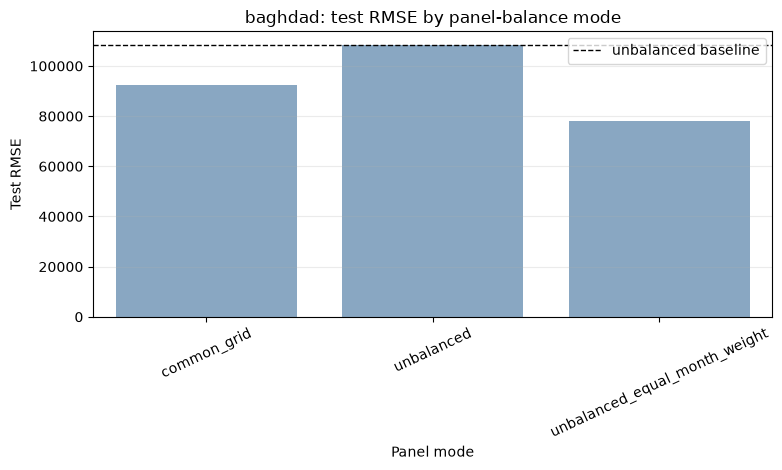

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/baghdad/panel_mode_test_rmse_comparison.png


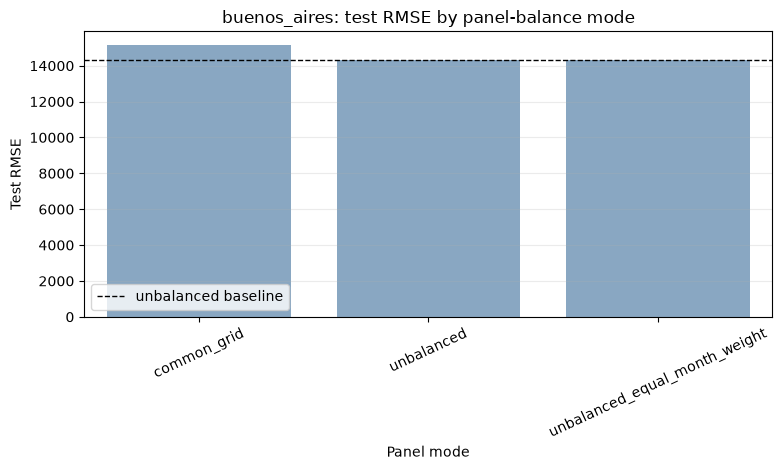

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/buenos_aires/panel_mode_test_rmse_comparison.png


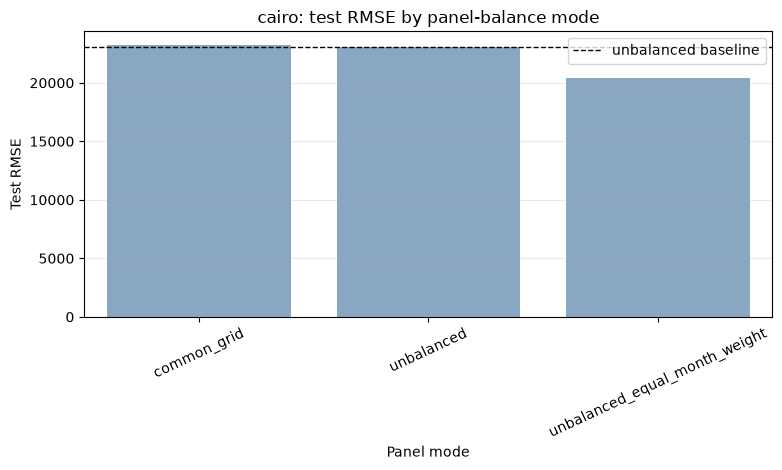

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/cairo/panel_mode_test_rmse_comparison.png


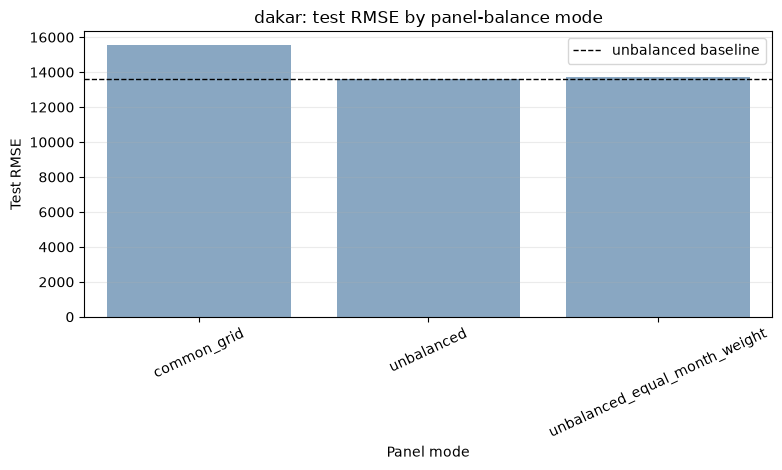

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/dakar/panel_mode_test_rmse_comparison.png


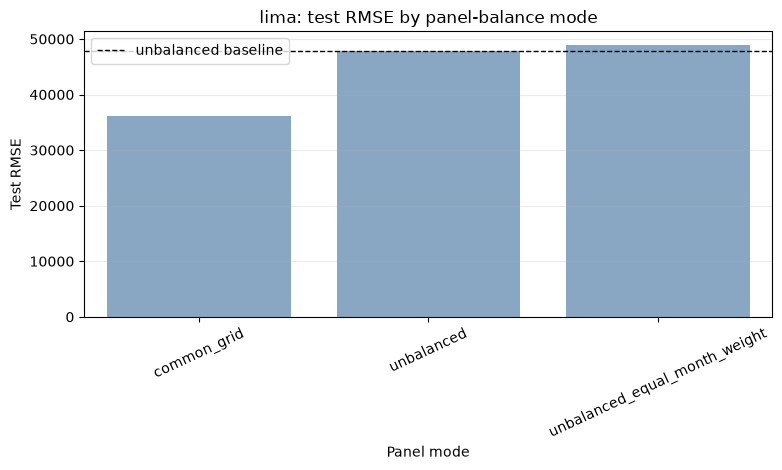

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/lima/panel_mode_test_rmse_comparison.png


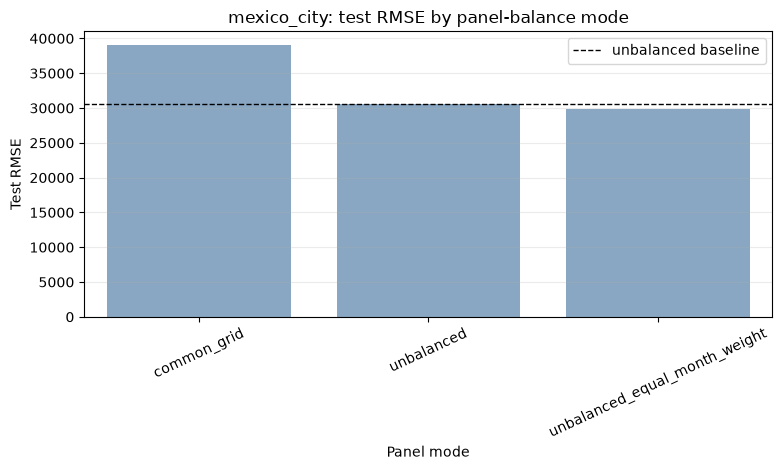

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/mexico_city/panel_mode_test_rmse_comparison.png


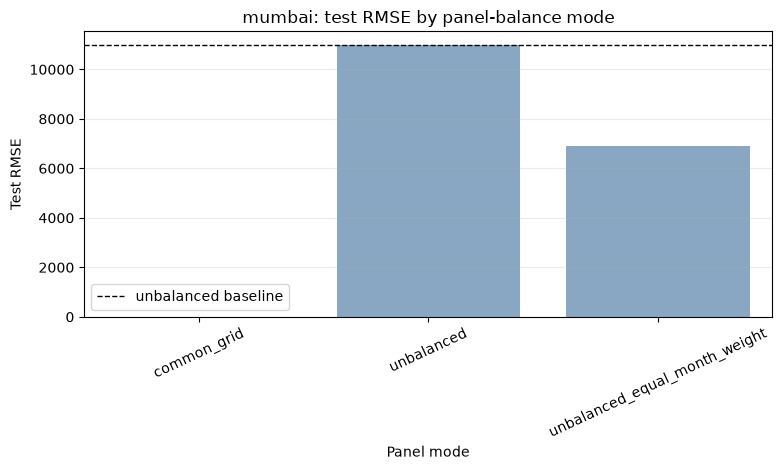

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/mumbai/panel_mode_test_rmse_comparison.png


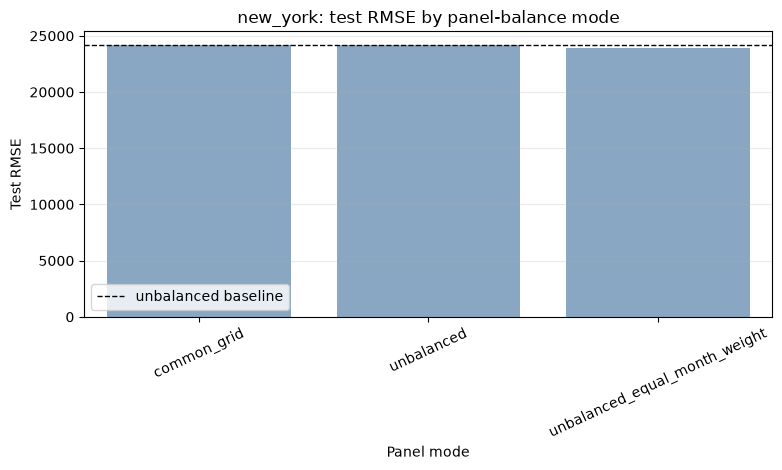

Saved panel-mode comparison figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/new_york/panel_mode_test_rmse_comparison.png


In [8]:
if not metrics_df.empty and "test_rmse" in metrics_df.columns:
    unbalanced_lookup = (
        metrics_df.loc[metrics_df["panel_mode"].eq("unbalanced"), ["city", "test_rmse", "test_mae", "test_r2"]]
        .rename(columns={
            "test_rmse": "unbalanced_test_rmse",
            "test_mae": "unbalanced_test_mae",
            "test_r2": "unbalanced_test_r2",
        })
    )
    comparison_df = metrics_df.merge(unbalanced_lookup, on="city", how="left")
    comparison_df["test_rmse_change_vs_unbalanced"] = comparison_df["test_rmse"] - comparison_df["unbalanced_test_rmse"]
    comparison_df["test_rmse_pct_change_vs_unbalanced"] = 100 * comparison_df["test_rmse_change_vs_unbalanced"] / comparison_df["unbalanced_test_rmse"]

    comparison_path = SCENARIO_OUTPUT_ROOT / "panel_mode_comparison_vs_unbalanced.csv"
    comparison_df.to_csv(comparison_path, index=False)
    print("Saved panel-mode comparison:", comparison_path)
    display(comparison_df[[
        "city", "panel_mode", "best_model_name", "test_rmse", "unbalanced_test_rmse",
        "test_rmse_change_vs_unbalanced", "test_rmse_pct_change_vs_unbalanced",
        "test_r2", "train_rows", "test_rows", "common_grid_count",
    ]].sort_values(["city", "panel_mode"]))

    for city, g in comparison_df.groupby("city"):
        plot_df = g.sort_values("panel_mode")
        fig, ax = plt.subplots(figsize=(8, 4.8))
        sns.barplot(data=plot_df, x="panel_mode", y="test_rmse", ax=ax, color="#7FA7CC")
        ax.axhline(plot_df.loc[plot_df["panel_mode"].eq("unbalanced"), "test_rmse"].iloc[0], color="black", linestyle="--", linewidth=1, label="unbalanced baseline")
        ax.set_title(f"{city}: test RMSE by panel-balance mode")
        ax.set_xlabel("Panel mode")
        ax.set_ylabel("Test RMSE")
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)
        ax.legend()
        fig.tight_layout()
        fig_path = SCENARIO_OUTPUT_ROOT / city / "panel_mode_test_rmse_comparison.png"
        fig.savefig(fig_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved panel-mode comparison figure:", fig_path)


## 7. Seen vs Unseen Grid Test Diagnostics

This section separates held-out test rows into two groups:

- **Seen grids:** grid cells that appeared during model development months;
- **Unseen grids:** grid cells that appear in the test period but did not appear during development months.

This distinction matters because the test task can mix two forms of prediction:

- temporal prediction for grid cells already seen earlier in the year;
- spatiotemporal prediction for grid cells that are new in the test period.

If unseen-grid error is much higher, then the model is struggling with spatial generalization, not only future-month prediction.


,city,panel_mode,grid_seen_status,rows,rmse,mae,r2,actual_mean,predicted_mean,bias_pred_minus_actual
2,baghdad,common_grid,seen_in_development,3664,92402.770616,45753.680675,0.866396,126506.532417,135123.478492,8616.946075
0,baghdad,unbalanced,seen_in_development,5200,109226.642165,45675.879399,0.751310,91571.511810,94962.696010,3391.184200
1,baghdad,unbalanced,unseen_in_development,81,6731.899473,5234.384333,-0.262611,7040.860326,10141.934390,3101.074064
3,baghdad,unbalanced_equal_month_weight,seen_in_development,5200,78809.386114,34123.897580,0.870534,91571.511810,97471.455428,5899.943618
4,baghdad,unbalanced_equal_month_weight,unseen_in_development,81,6870.978796,5287.615247,-0.315321,7040.860326,9835.157093,2794.296767
7,buenos_aires,common_grid,seen_in_development,5086,15158.181654,8254.698621,0.902229,21350.965826,21435.223536,84.257710
5,buenos_aires,unbalanced,seen_in_development,5793,14303.461808,7436.151490,0.902721,19018.317840,18858.431260,-159.886580
6,buenos_aires,unbalanced,unseen_in_development,10,2007.519779,1568.099851,-0.482680,1909.731512,1606.816327,-302.915185
8,buenos_aires,unbalanced_equal_month_weight,seen_in_development,5793,14312.932434,7405.722213,0.902592,19018.317840,18654.853890,-363.463950
9,buenos_aires,unbalanced_equal_month_weight,unseen_in_development,10,2109.839824,1703.086515,-0.637672,1909.731512,1467.309694,-442.421818


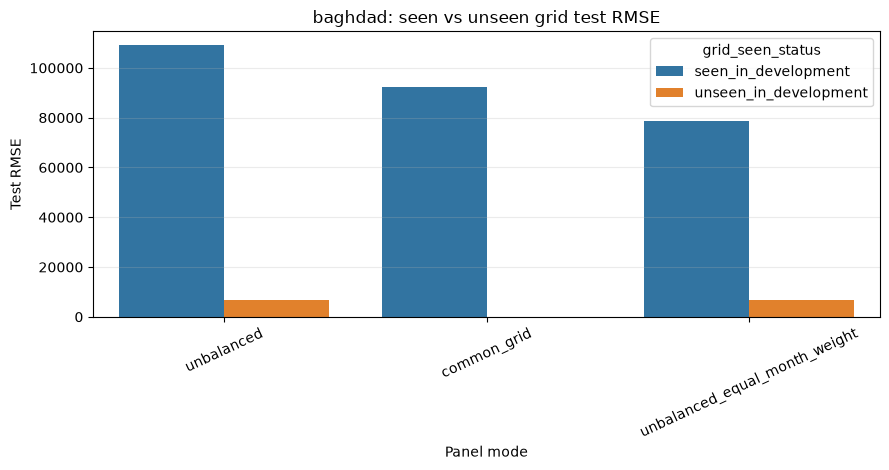

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/baghdad/seen_unseen_grid_test_rmse.png


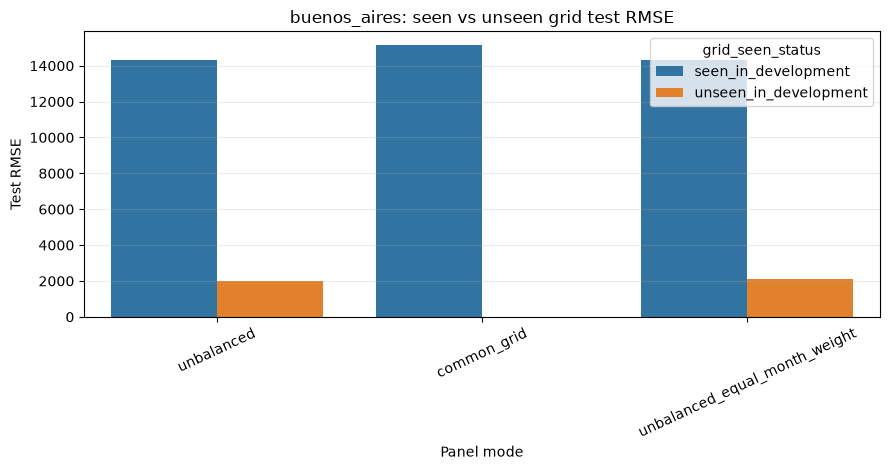

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/buenos_aires/seen_unseen_grid_test_rmse.png


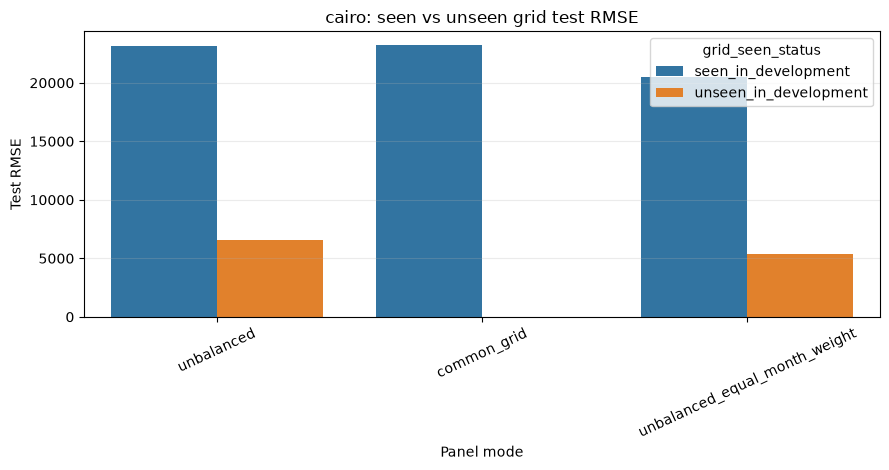

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/cairo/seen_unseen_grid_test_rmse.png


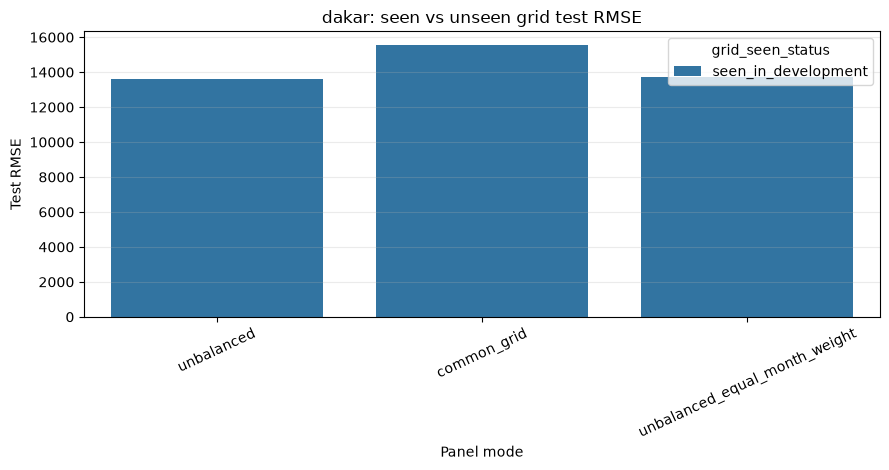

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/dakar/seen_unseen_grid_test_rmse.png


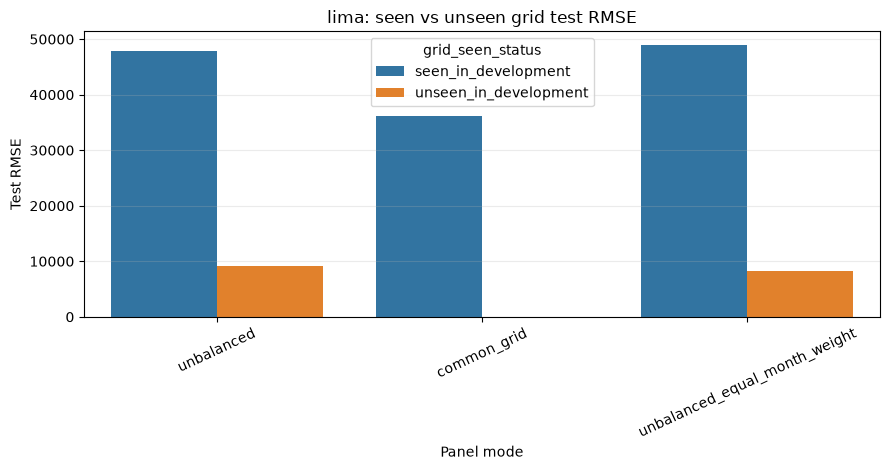

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/lima/seen_unseen_grid_test_rmse.png


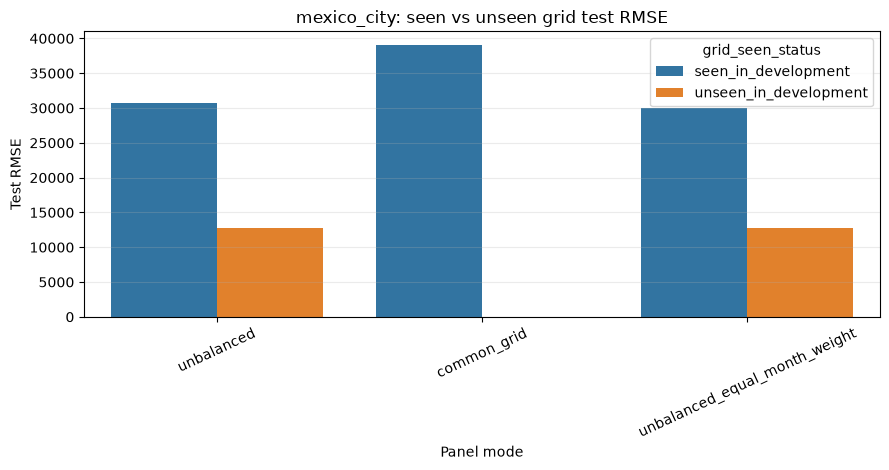

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/mexico_city/seen_unseen_grid_test_rmse.png


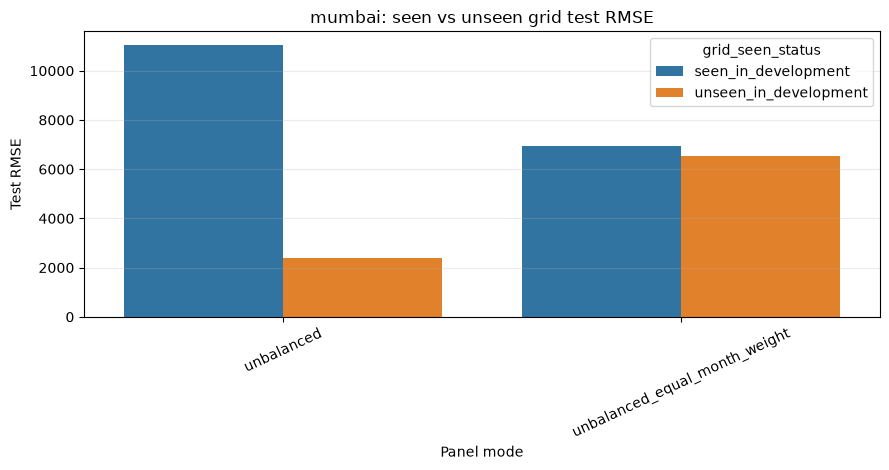

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/mumbai/seen_unseen_grid_test_rmse.png


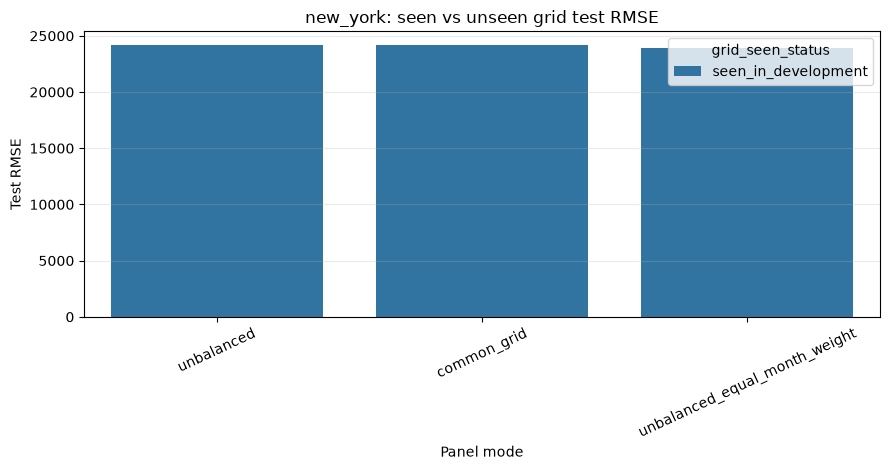

Saved seen/unseen test figure: NO2_Mobility_Project/data/ModelOutputs/tci_panel_balance_robustness_v26/train_1_8_validate_9_10_test_11_12_balance_robustness/new_york/seen_unseen_grid_test_rmse.png


In [9]:
if seen_unseen_metrics_df.empty:
    print("No seen/unseen metrics were created.")
else:
    display(seen_unseen_metrics_df.sort_values(["city", "panel_mode", "grid_seen_status"])[[
        "city", "panel_mode", "grid_seen_status", "rows", "rmse", "mae", "r2", "actual_mean", "predicted_mean", "bias_pred_minus_actual",
    ]])

    for city, g in seen_unseen_metrics_df.groupby("city"):
        fig, ax = plt.subplots(figsize=(9, 4.8))
        sns.barplot(
            data=g,
            x="panel_mode",
            y="rmse",
            hue="grid_seen_status",
            ax=ax,
        )
        ax.set_title(f"{city}: seen vs unseen grid test RMSE")
        ax.set_xlabel("Panel mode")
        ax.set_ylabel("Test RMSE")
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        fig_path = SCENARIO_OUTPUT_ROOT / city / "seen_unseen_grid_test_rmse.png"
        fig.savefig(fig_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved seen/unseen test figure:", fig_path)


## 8. Interpretation Guide

Use this robustness check as a companion to the main tuned model, not as a replacement for the main model-selection workflow.

Interpretation rules:

- If `common_grid` is close to `unbalanced`, the main conclusions are probably not driven by changing grid composition across months.
- If `common_grid` is much better or worse, changing grid availability is affecting the results and should be reported.
- If `unbalanced_equal_month_weight` differs strongly from `unbalanced`, months with more rows were influencing model training more heavily.
- If unseen-grid RMSE is much worse than seen-grid RMSE, the task includes a spatial-generalization challenge in addition to temporal prediction.

For reporting, the cleanest structure is to present the unbalanced model as the realistic prediction setting and use the common-grid and equal-month-weight results as robustness checks.
